# VarDyn QG 
This notebook, associated to its configuration file, runs a VarDyn reconstruction for the Gulf Stream region in the eNATL60-BLB002 simulation. 
The model is a 1.5 layer quasi-geostrophic model, and the reduced basis is made of empirical modes with a spatially variable time decorrelation scale. 
The observations are nadir along-track SSH observations from 6 different altimetry missions (AL, C2, H2B, J3, S3A and S3B) and SWOT swath SSH observations. 

In [61]:
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = '0'    
from datetime import datetime

## Configuration file

In [62]:
# BLB002
# path_config = '/data2/nora/Workdir/VarDyn/configs_runs/BLB002/config_VarDyn-QG_barotrop_eNATL60-BLB002.py' 

# BLBT02
# path_config = '/data2/nora/Workdir/VarDyn/configs_runs/BLBT02/config_VarDyn-QG_barotrop_eNATL60-BLBT02.py' 

# SWOT BLB002
# path_config = '/data2/nora/Workdir/VarDyn/configs_runs/SWOT/config_VarDyn-QG_eNATL60-BLB002_SWOT.py'

#SWOT BLBT02
path_config = '/data2/nora/Workdir/VarDyn/configs_runs/SWOT/config_VarDyn-QG_eNATL60-BLBT02_SWOT.py'

In [63]:
import sys
sys.path.append('/home/nora/VarDyn/mapping')

In [64]:

from src import exp
config = exp.Exp(path_config)

name_experiment: VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_SWOT_23_04
saveoutputs: True
name_exp_save: VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_SWOT_23_04
path_save: /data2/nora/Workdir/VarDyn/outputs/BLBT02/SWOT/VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_SWOT_23_04
tmp_DA_path: /data2/nora/Workdir/VarDyn/scratch/VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_SWOT_23_04
init_date: 2009-07-11 00:00:00
final_date: 2010-02-16 00:00:00
assimilation_time_step: 6:00:00
saveoutput_time_step: 6:00:00
flag_plot: 1
write_obs: True
path_obs: /data2/nora/Workdir/VarDyn/obs
compute_obs: True
name_lon: lon
name_lat: lat
name_time: time
plot_time_step: 1 day, 0:00:00
time_obs_min: None
time_obs_max: None
lon_obs_min: None
lon_obs_max: None
lat_obs_min: None
lat_obs_max: None



## State

In [65]:
from src import state as state
State = state.State(config)

super: GRID_CAR
lon_min: -65
lon_max: -55
lat_min: 33
lat_max: 43
dx: 5
nx: None
ny: None
name_init_mask: /data1/data/models/eNATL60/BLBT02/coarsened/eNATL60-BLBT02_coarse-5_rolling-10.nc
name_var_mask: {'lon': 'lon', 'lat': 'lat', 'var': 'ssh'}



## Model

super: MOD_DIFF
name_var: {'SSH': 'ssh_barotrop'}
var_to_save: None
name_init_var: {'SSH': 'ssh_barotrop'}
dtmodel: 1800
Kdiffus: 0
SIC_mod: False
init_from_bc: False
dist_sponge_bc: None


super: MOD_QG1L_JAX
name_class: Qgm
name_var: {'SSH': 'ssh'}
name_init_var: {'SSH': 'ssh'}
dir_model: None
var_to_save: None
save_diagnosed_variables: False
save_params: False
upwind: 3
advect_pv: True
advect_tracer: False
dtmodel: 1800
cfl: 0.1
time_scheme: rk2
c0: 2.7
filec_aux: /home/nora/VarDyn/mapping/aux/aux_first_baroclinic_speed.nc
name_var_c: {'lon': 'lon', 'lat': 'lat', 'var': 'c1'}
cmin: 2.0
cmax: None
file_bathy_aux: None
name_var_bathy: {'lon': '', 'lat': '', 'var': ''}
bathy_ratio_max: None
solver: spectral
init_from_bc: True
dist_sponge_bc: None
Kdiffus: 150
Kdiffus_trac: None
bc_trac: OBC
forcing_tracer_from_bc: False
constant_c: True
constant_f: True
f0: None
tile_size: 32
tile_overlap: 16
path_mdt: None
name_var_mdt: None



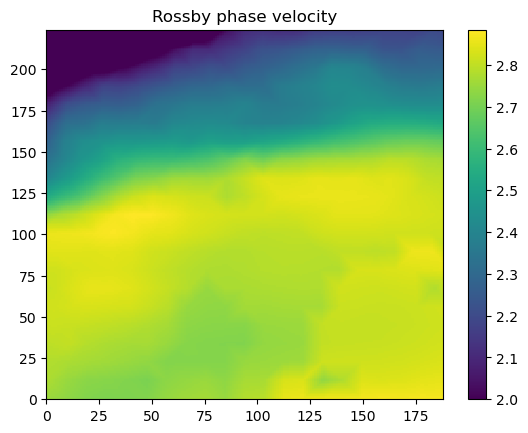

CFL condition for c= 2.627374482098144
Model time-step 180



In [66]:
from src import mod as mod
Model = mod.Model(config,State)

In [67]:
from src import bc as bc
Bc = bc.Bc(config)

super: BC_EXT
file: /data1/data/models/eNATL60/BLBT02/coarsened/eNATL60-BLBT02_coarse-5_rolling-10.nc
name_lon: lon
name_lat: lat
name_time: time
name_var: {'SSH': 'ssh'}
c_grid: False



## Observations

In [68]:
from src import obs as obs
dict_obs = obs.Obs(config,State)

Observation information will be saved in dict_obs_AL_C2_H2B_J3_S3A_S3B_S6A_SWOT_20090711_20100216_-65_-54_33_43_21600.txt

AL:
super: OBS_SSH_NADIR
path: /data1/data/models/eNATL60/BLBT02/obs/nadirs/al.nc
name_time: time
name_lon: lon
name_lat: lat
name_var: {'SSH': 'ssh'}
combine_var: None
synthetic_noise: None
varmax: 100.0
sigma_noise: 0.1
add_mdt: None
substract_mdt: None
path_mdt: None
name_var_mdt: None
path_err: None
name_var_err: None
nudging_params_ssh: None
delta_t: None
velocity: None

--> 217 tracks selected

C2:
super: OBS_SSH_NADIR
path: /data1/data/models/eNATL60/BLBT02/obs/nadirs/c2.nc
name_time: time
name_lon: lon
name_lat: lat
name_var: {'SSH': 'ssh'}
combine_var: None
synthetic_noise: None
varmax: 100.0
sigma_noise: 0.1
add_mdt: None
substract_mdt: None
path_mdt: None
name_var_mdt: None
path_err: None
name_var_err: None
nudging_params_ssh: None
delta_t: None
velocity: None

--> 227 tracks selected

H2B:
super: OBS_SSH_NADIR
path: /data1/data/models/eNATL60/BLBT02/obs

In [69]:
from src import obsop as obsop
Obsop = obsop.Obsop(config,State,dict_obs,Model)

myOBSOP1: super: OBSOP_INTERP_L3_JAX
name_obs: ['AL', 'C2', 'H2B', 'J3', 'S3A', 'S3B', 'S6A']
name_var: SSH
write_op: True
path_save: /data2/nora/Workdir/VarDyn/H
compute_op: True
Npix: 4
mask_borders: False

myOBSOP2: super: OBSOP_INTERP_L4
name_obs: ['SWOT']
name_var: SSH
write_op: True
path_save: /data2/nora/Workdir/VarDyn/H
compute_op: True
mask_borders: False
interp_method: rtree
gradients: False


super: OBSOP_INTERP_L3_JAX
name_obs: ['AL', 'C2', 'H2B', 'J3', 'S3A', 'S3B', 'S6A']
name_var: SSH
write_op: True
path_save: /data2/nora/Workdir/VarDyn/H
compute_op: True
Npix: 4
mask_borders: False

super: OBSOP_INTERP_L4
name_obs: ['SWOT']
name_var: SSH
write_op: True
path_save: /data2/nora/Workdir/VarDyn/H
compute_op: True
mask_borders: False
interp_method: rtree
gradients: False



## Reduced Basis

In [70]:
from src import basis as basis
Basis = basis.Basis(config,State)

super: BASIS_GAUSS3D_JAX
name_mod_var: ssh_barotrop
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: True
facns: 3.0
facnlt: 3.0
sigma_D: 1000
sigma_T: 3
sigma_Q: 0.05
fcor: 0.5
normalize_fact: True
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: None
path_background: None
var_background: None

super: BASIS_GAUSS3D_JAX
name_mod_var: ssh
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: True
facns: 3.0
facnlt: 3.0
sigma_D: 970
sigma_T: 25
sigma_Q: 0.03
fcor: 0.5
normalize_fact: True
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: {'lon': '', 'lat': '', 'var': ''}
path_background: None
var_background: None

super: BASIS_BMaux_JAX
name_mod_var: ssh
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: False
facns: 1.0
facnlt: 2.0
npsp: 3.5
facpsp: 1.5
file_aux: /home/nora/VarDyn/mapping/aux/aux_reduced_basis_BM.nc
lmin: 80
lmax: 1000.0
factdec: 7.5
tdecmin: 2.0
tdecmax

## Assimilation

super: INV_4DVAR
flag_full_jax: False
compute_test: False
freq_it_plot: 10
JAX_mem_fraction: None
path_init_4Dvar: None
restart_4Dvar: True
ftol: 1e-05
gtol: None
convergence_nit: None
maxiter: 500
gradient_max_norm: 1000000.0
max_retries: 3
opt_method: L-BFGS-B
save_minimization: True
path_save_control_vectors: /data2/nora/Workdir/VarDyn/controls/BLBT02/SWOT/VarDyn-QG_eNATL60-BLBT02_GulfStream_1y_SWOT_23_04
timestep_checkpoint: 6:00:00
sigma_R: None
sigma_B: None
prec: True
path_background: None
anomaly_from_bc: False

process observation operators
Processing observations at date 2009-07-24 12:00:00 for variable SSH...
2009-07-24 12:00:00 1166400
Processing observations at date 2009-07-26 00:00:00 for variable SSH...
Processing observations at date 2009-07-26 12:00:00 for variable SSH...
Processing observations at date 2009-07-27 00:00:00 for variable SSH...
Processing observations at date 2009-07-27 12:00:00 for variable SSH...
Processing observations at date 2009-07-28 00:00:00 for 

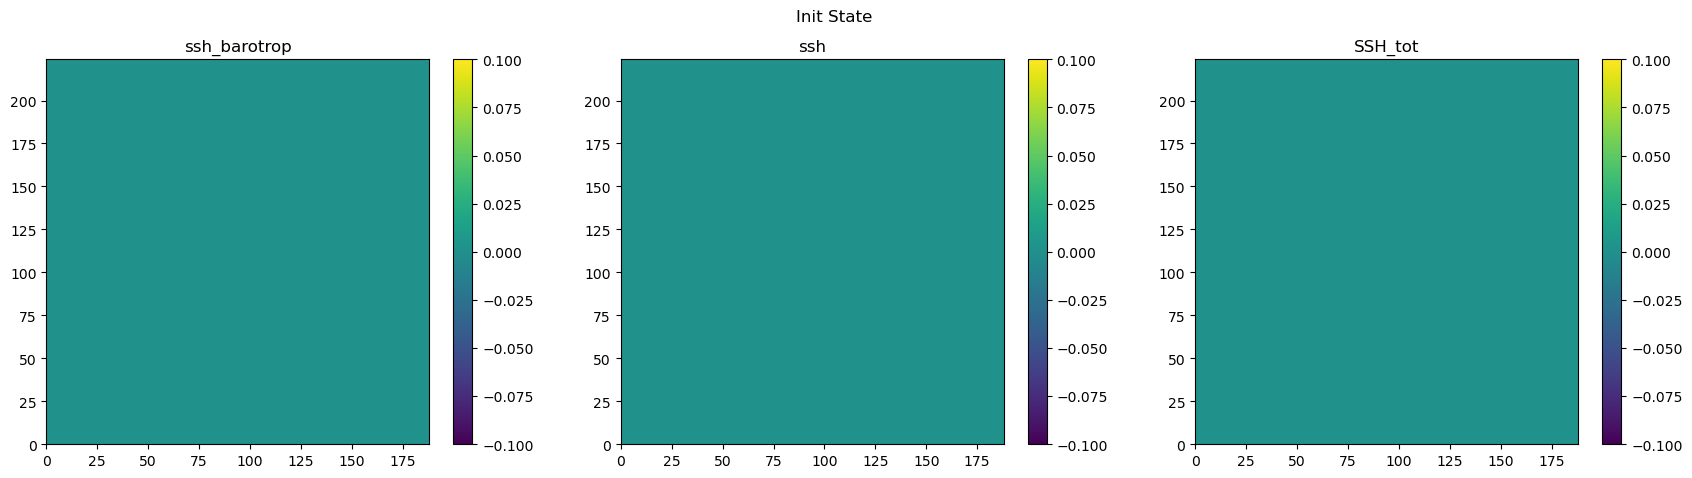

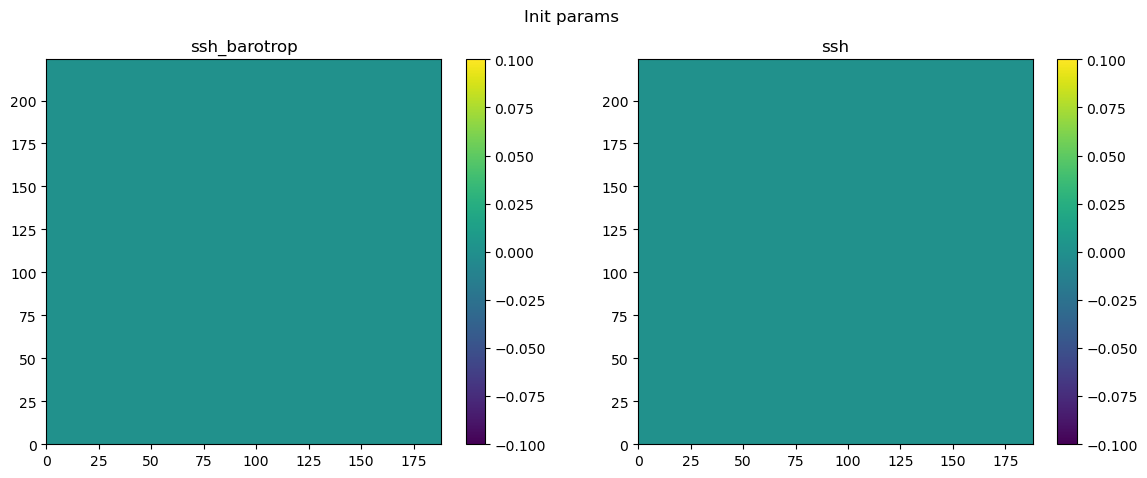

Running basis: <class 'src.basis.Basis_gauss3d_jax'> no_name
lambda=1.0E+03 nlocs=6.2E+01 tdec=3.0E+00 ntime=2.2E+02 Q=1.7E-02
reduced order: 37100672 --> 13888
 reduced factor: 2671
Running basis: <class 'src.basis.Basis_gauss3d_jax'> no_name
lambda=9.7E+02 nlocs=6.0E+01 tdec=2.5E+01 ntime=3.0E+01 Q=1.0E-02
reduced order: 37100672 --> 1800
 reduced factor: 20611
Running basis: <class 'src.basis.Basis_bmaux_jax'> no_name
Setting Basis BMaux...
Computing Q
lambda=1.4E+03 nlocs=1.0E+01 tdec=2.0E+00 Q=1.0E-10
lambda=9.7E+02 nlocs=1.0E+01 tdec=1.3E+01 Q=1.1E-03
lambda=6.8E+02 nlocs=1.2E+01 tdec=1.0E+01 Q=2.3E-03
lambda=4.8E+02 nlocs=1.7E+01 tdec=9.5E+00 Q=3.7E-03
lambda=3.3E+02 nlocs=2.4E+01 tdec=8.1E+00 Q=4.4E-03
lambda=2.3E+02 nlocs=3.2E+01 tdec=6.3E+00 Q=4.3E-03
lambda=1.6E+02 nlocs=4.7E+01 tdec=3.9E+00 Q=2.4E-03
lambda=1.1E+02 nlocs=6.4E+01 tdec=2.7E+00 Q=2.0E-03
lambda=8.0E+01 nlocs=1.1E+02 tdec=2.3E+00 Q=1.2E-03
Computing Spatial components
Computing Time components
reduced order: 37

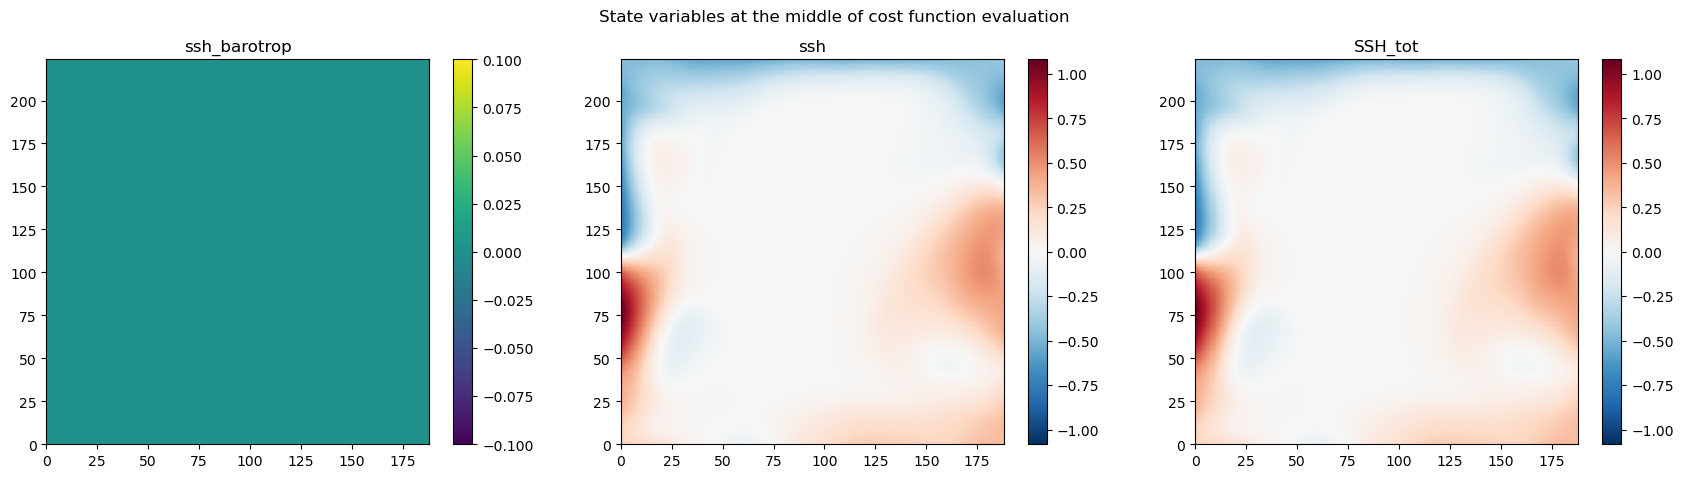

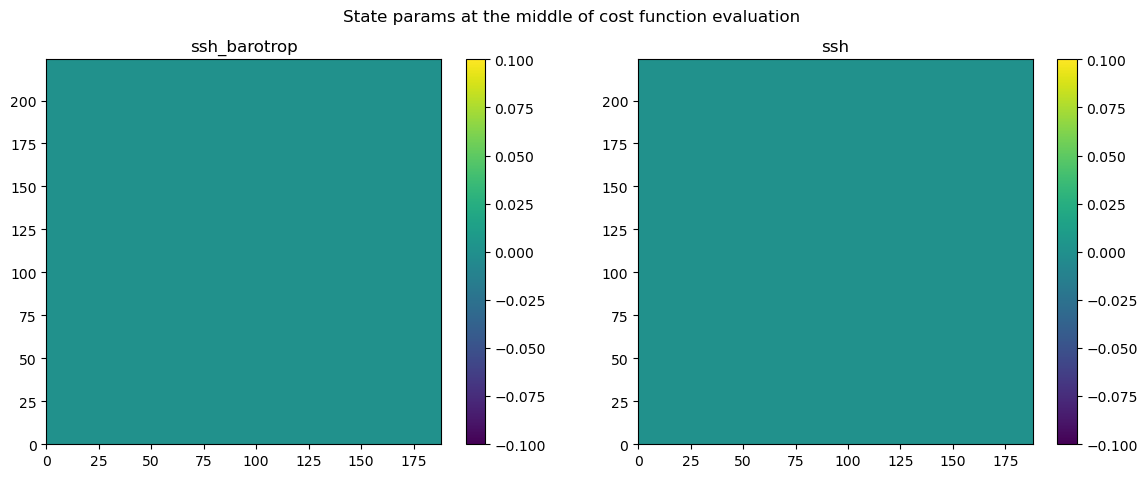

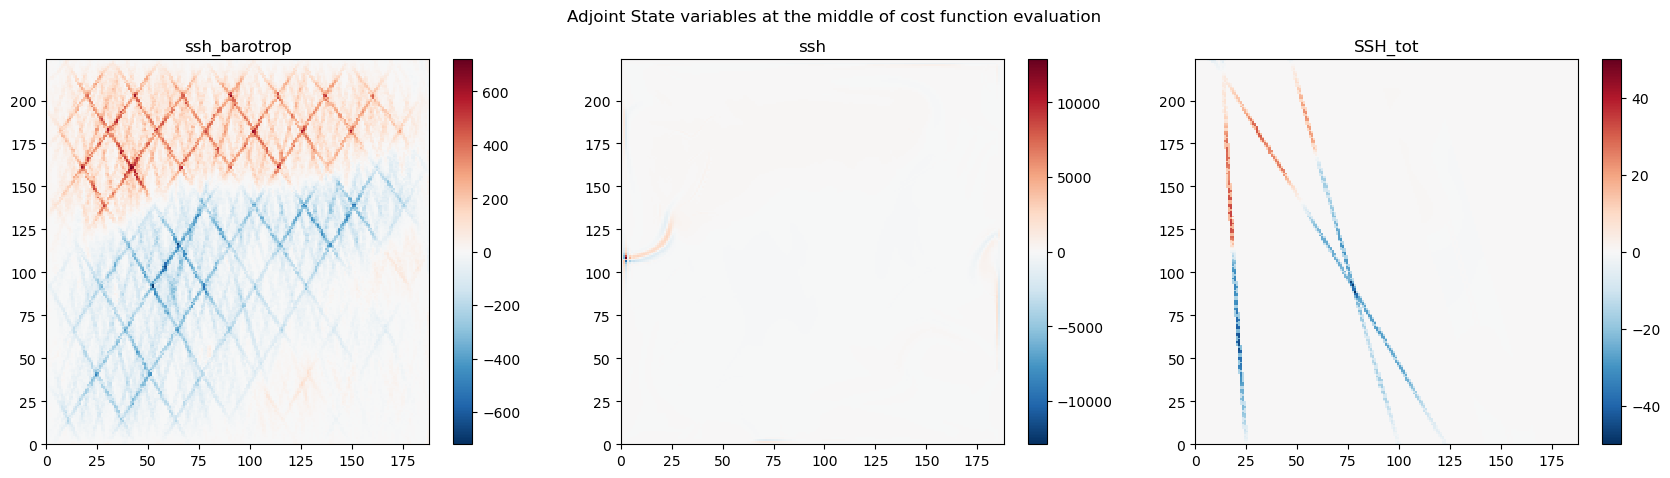

* iteration 1 computed in 4.70E+01 second:, x=0.00E+00, J=1.64E+06, G=1.62E+01, ftol=4.58E-12, gtol=1.18E-07
* iteration 2 computed in 4.62E+01 second:, x=9.36E-06, J=1.49E+06, G=1.49E+01, ftol=9.23E-02, gtol=8.00E-02
* iteration 3 computed in 4.71E+01 second:, x=1.19E-04, J=8.94E+05, G=9.82E+00, ftol=3.98E-01, gtol=3.40E-01
* iteration 4 computed in 4.62E+01 second:, x=1.08E-04, J=7.90E+05, G=7.87E+00, ftol=1.16E-01, gtol=1.99E-01
* iteration 5 computed in 4.68E+01 second:, x=1.04E-04, J=7.34E+05, G=5.60E+00, ftol=7.17E-02, gtol=2.88E-01
* iteration 6 computed in 4.56E+01 second:, x=1.12E-04, J=6.90E+05, G=5.85E+00, ftol=5.94E-02, gtol=4.27E-02
* iteration 7 computed in 4.71E+01 second:, x=1.28E-04, J=6.64E+05, G=7.00E+00, ftol=3.75E-02, gtol=1.64E-01
* iteration 8 computed in 4.57E+01 second:, x=1.34E-04, J=6.32E+05, G=5.93E+00, ftol=4.89E-02, gtol=1.53E-01
* iteration 9 computed in 4.65E+01 second:, x=1.46E-04, J=5.84E+05, G=8.98E+00, ftol=7.61E-02, gtol=3.39E-01


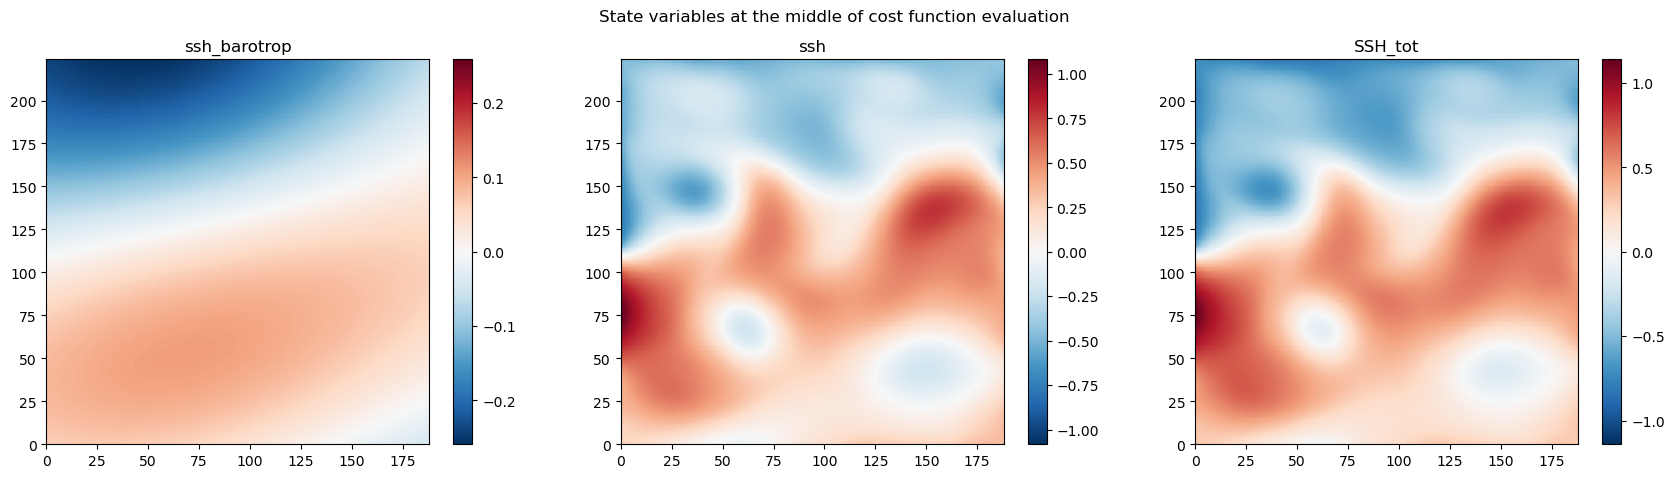

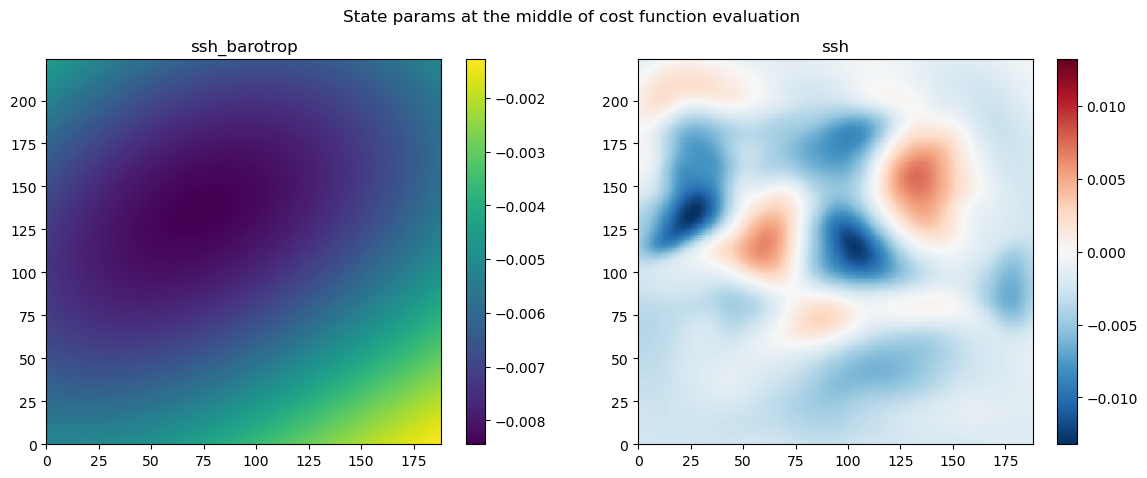

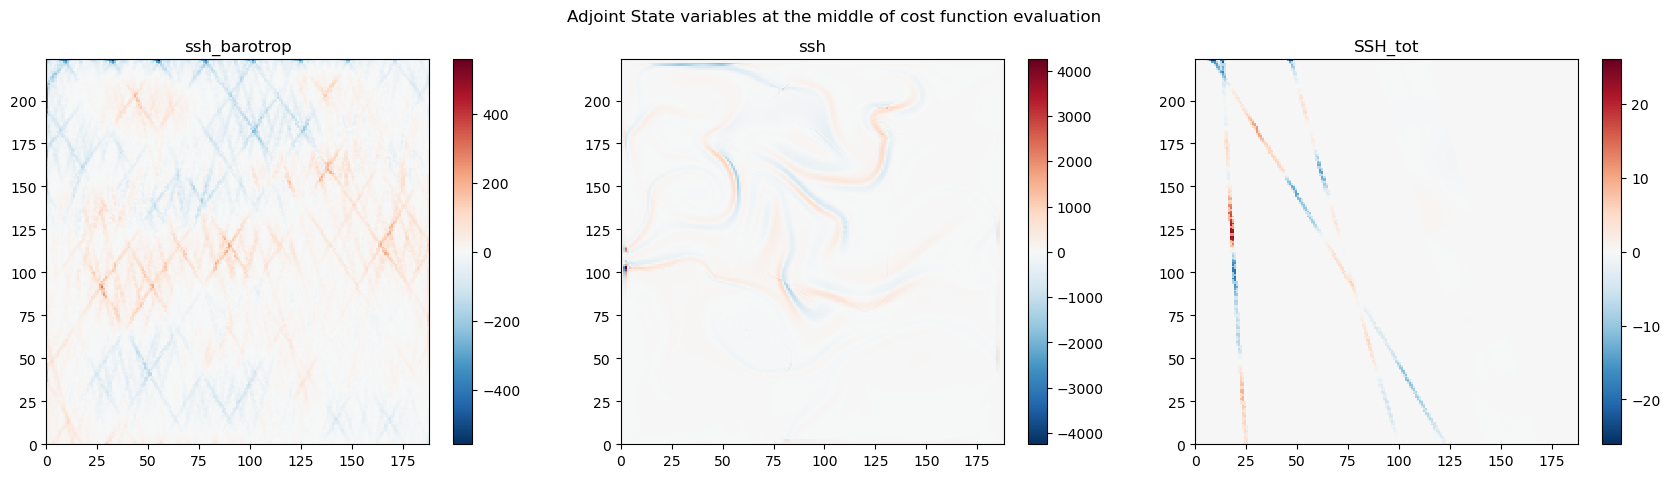

* iteration 10 computed in 4.74E+01 second:, x=1.48E-04, J=5.76E+05, G=1.04E+01, ftol=1.25E-02, gtol=1.33E-01
* iteration 11 computed in 4.66E+01 second:, x=1.38E-04, J=5.53E+05, G=7.06E+00, ftol=3.97E-02, gtol=3.18E-01
* iteration 12 computed in 4.77E+01 second:, x=1.31E-04, J=5.29E+05, G=5.63E+00, ftol=4.46E-02, gtol=2.03E-01
* iteration 13 computed in 4.69E+01 second:, x=1.32E-04, J=5.07E+05, G=4.41E+00, ftol=4.08E-02, gtol=2.16E-01
* iteration 14 computed in 4.71E+01 second:, x=1.33E-04, J=4.86E+05, G=5.46E+00, ftol=4.08E-02, gtol=1.93E-01
* iteration 15 computed in 4.61E+01 second:, x=1.30E-04, J=5.04E+05, G=1.44E+01, ftol=3.47E-02, gtol=6.21E-01
* iteration 16 computed in 4.73E+01 second:, x=1.32E-04, J=4.82E+05, G=6.51E+00, ftol=4.33E-02, gtol=5.48E-01
* iteration 17 computed in 4.72E+01 second:, x=1.33E-04, J=4.76E+05, G=6.09E+00, ftol=1.28E-02, gtol=6.54E-02
* iteration 18 computed in 4.66E+01 second:, x=1.36E-04, J=4.69E+05, G=6.02E+00, ftol=1.58E-02, gtol=1.13E-02
* iteratio

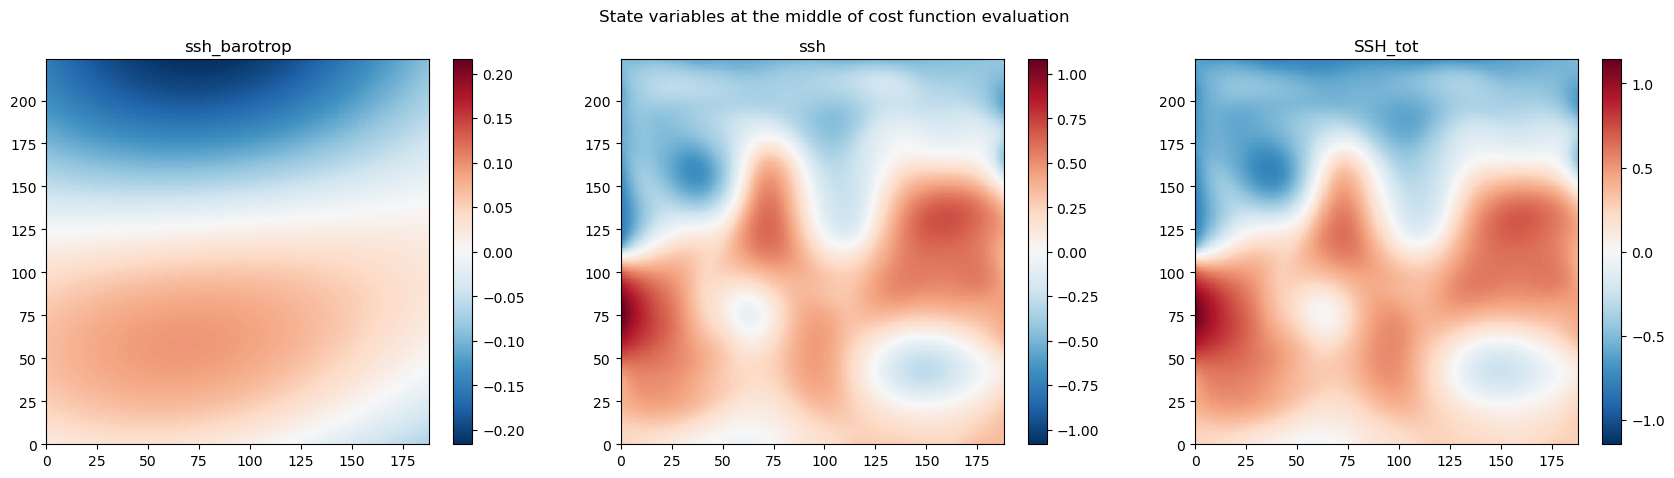

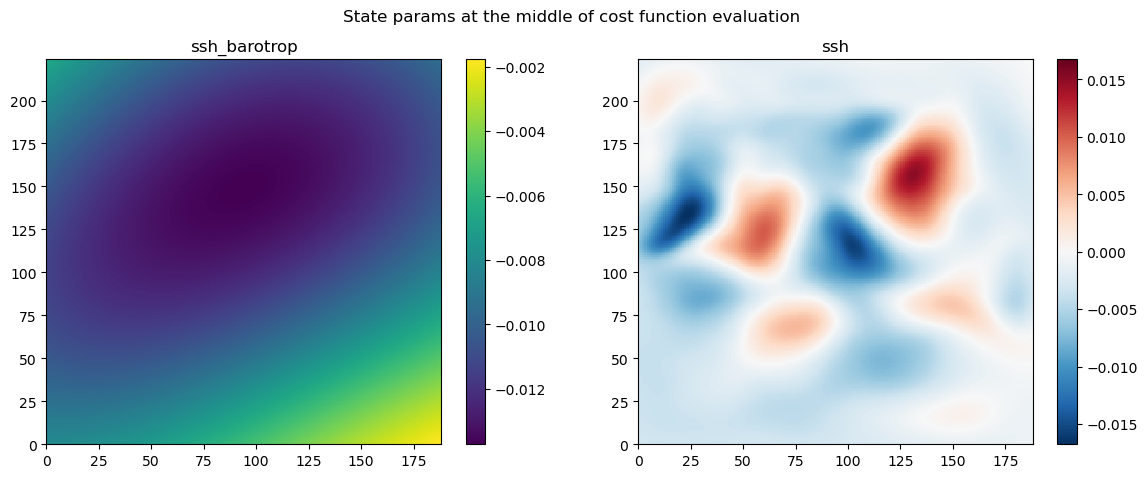

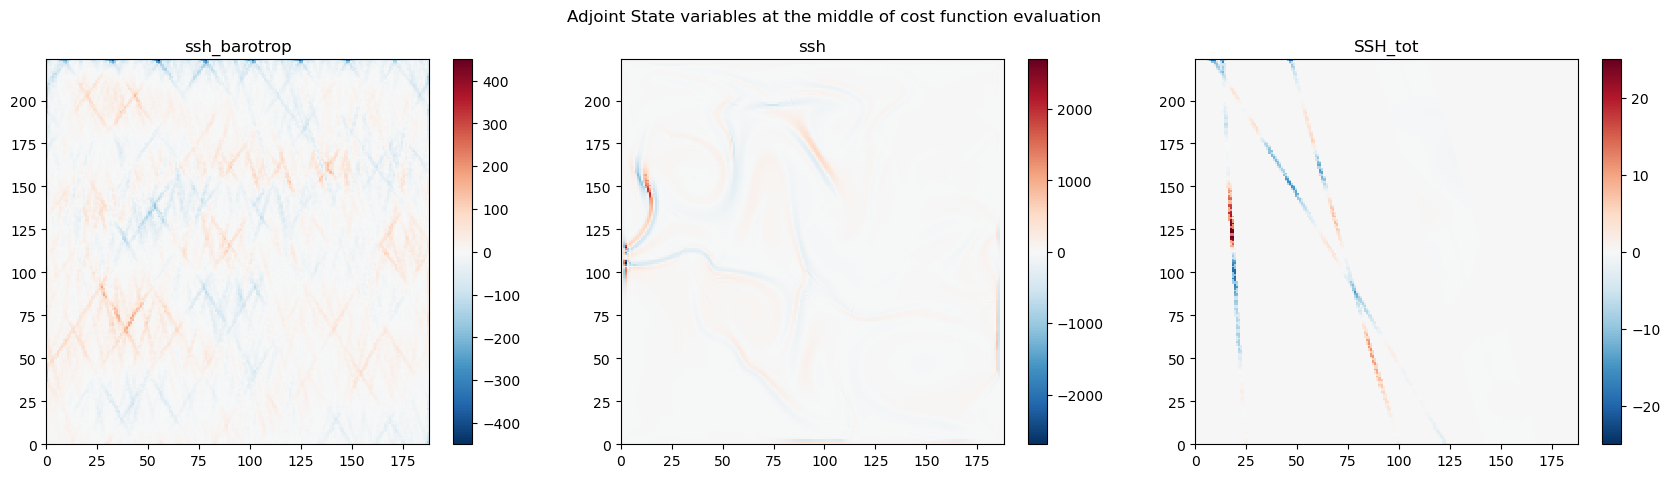

* iteration 20 computed in 4.90E+01 second:, x=1.39E-04, J=4.53E+05, G=5.36E+00, ftol=1.91E-02, gtol=5.19E-02
* iteration 21 computed in 4.75E+01 second:, x=1.35E-04, J=4.60E+05, G=1.39E+01, ftol=1.53E-02, gtol=6.15E-01
* iteration 22 computed in 4.74E+01 second:, x=1.38E-04, J=4.48E+05, G=7.44E+00, ftol=2.62E-02, gtol=4.65E-01
* iteration 23 computed in 4.65E+01 second:, x=1.31E-04, J=4.42E+05, G=6.43E+00, ftol=1.46E-02, gtol=1.36E-01
* iteration 24 computed in 4.69E+01 second:, x=1.27E-04, J=4.39E+05, G=1.23E+01, ftol=6.88E-03, gtol=4.77E-01
* iteration 25 computed in 4.67E+01 second:, x=1.26E-04, J=4.35E+05, G=4.47E+00, ftol=7.99E-03, gtol=6.36E-01
* iteration 26 computed in 4.57E+01 second:, x=1.23E-04, J=4.31E+05, G=6.53E+00, ftol=8.94E-03, gtol=3.15E-01
* iteration 27 computed in 4.71E+01 second:, x=1.19E-04, J=4.26E+05, G=7.35E+00, ftol=1.22E-02, gtol=1.12E-01
* iteration 28 computed in 4.74E+01 second:, x=1.13E-04, J=4.20E+05, G=8.10E+00, ftol=1.37E-02, gtol=9.28E-02
* iteratio

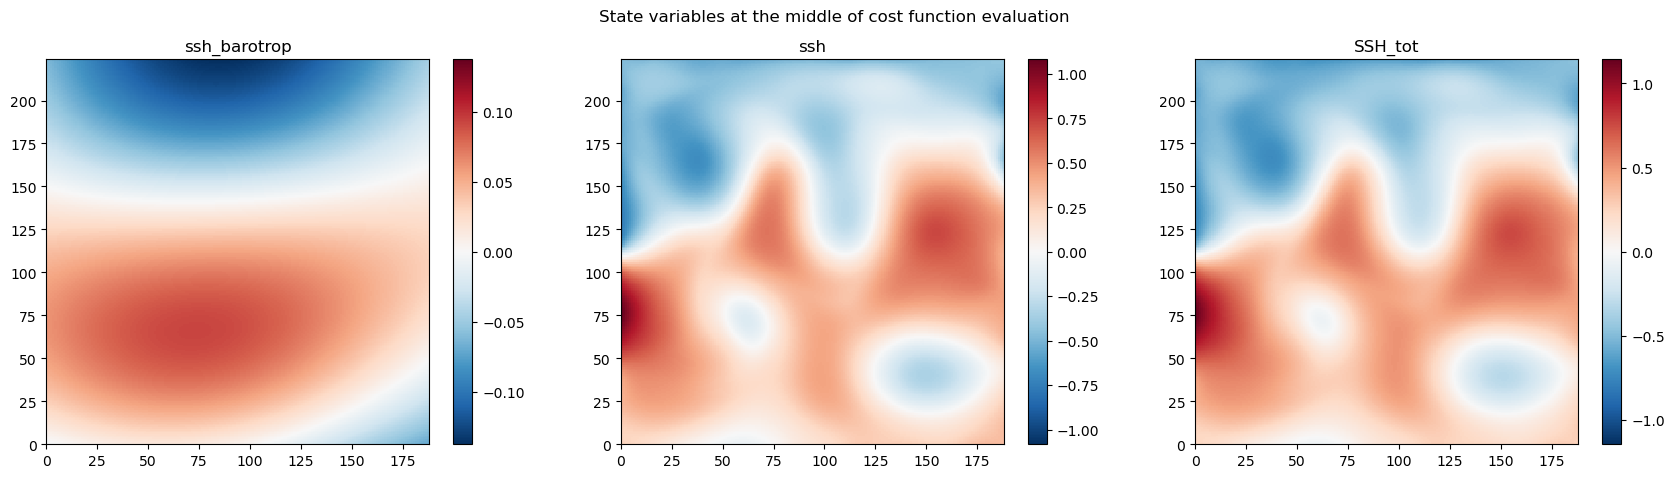

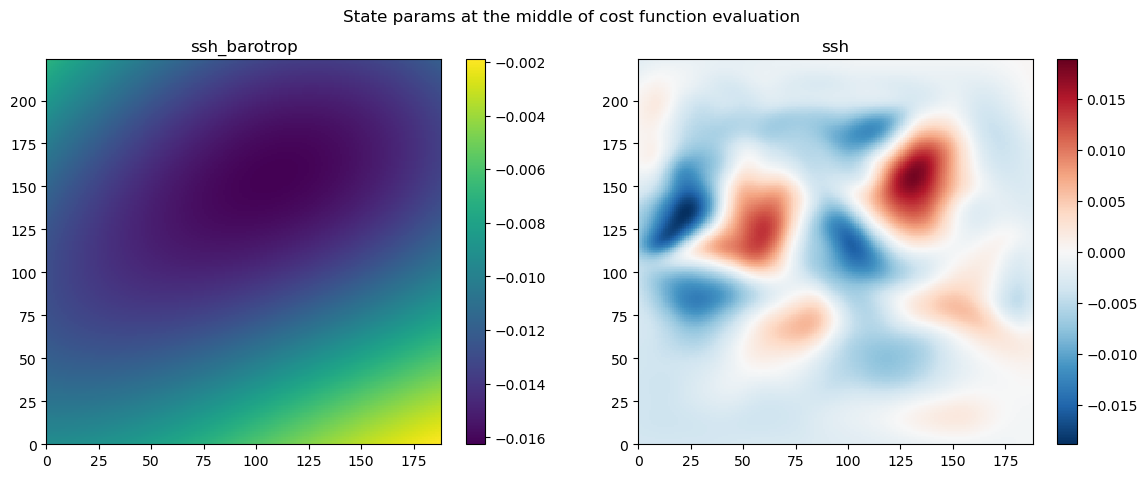

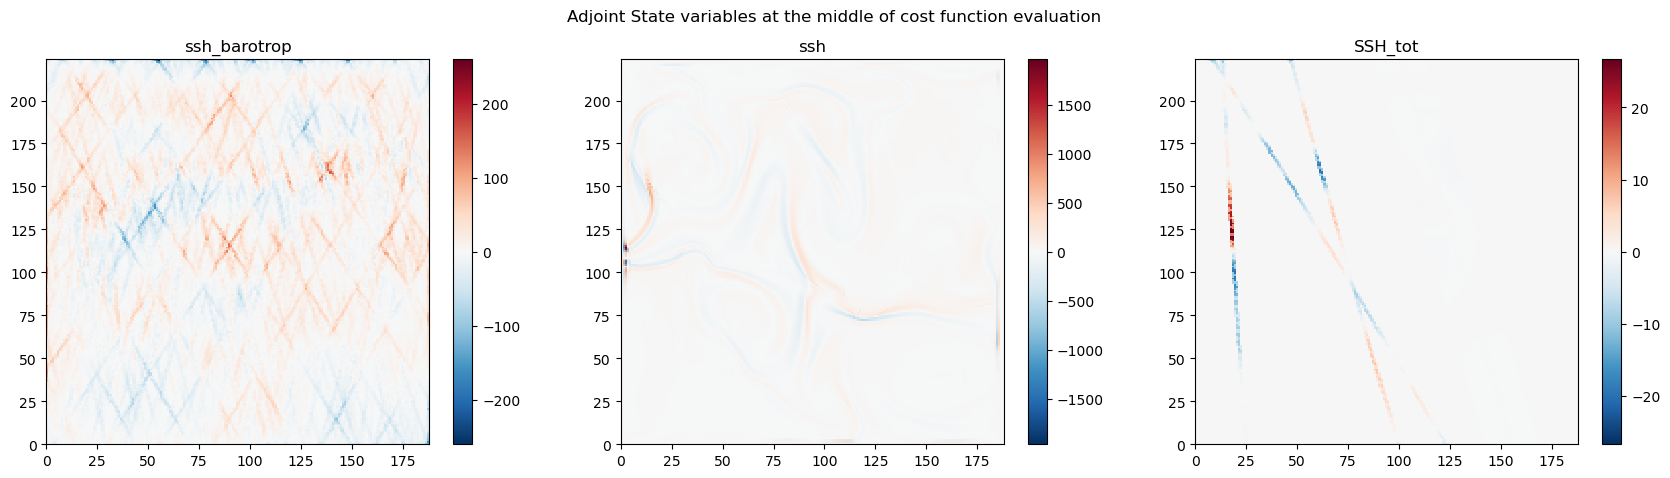

* iteration 30 computed in 4.89E+01 second:, x=1.12E-04, J=4.10E+05, G=5.11E+00, ftol=1.43E-02, gtol=5.06E-01
* iteration 31 computed in 4.72E+01 second:, x=1.11E-04, J=4.06E+05, G=3.88E+00, ftol=9.26E-03, gtol=2.41E-01
* iteration 32 computed in 4.74E+01 second:, x=1.07E-04, J=4.01E+05, G=5.55E+00, ftol=1.25E-02, gtol=3.02E-01
* iteration 33 computed in 4.57E+01 second:, x=1.05E-04, J=3.96E+05, G=4.81E+00, ftol=1.25E-02, gtol=1.34E-01
* iteration 34 computed in 4.71E+01 second:, x=1.02E-04, J=3.91E+05, G=4.04E+00, ftol=1.35E-02, gtol=1.59E-01
* iteration 35 computed in 4.75E+01 second:, x=9.41E-05, J=3.84E+05, G=1.01E+01, ftol=1.67E-02, gtol=5.98E-01
* iteration 36 computed in 4.64E+01 second:, x=9.03E-05, J=3.78E+05, G=4.56E+00, ftol=1.62E-02, gtol=5.47E-01
* iteration 37 computed in 4.70E+01 second:, x=8.46E-05, J=3.74E+05, G=5.28E+00, ftol=1.05E-02, gtol=1.37E-01
* iteration 38 computed in 4.61E+01 second:, x=7.65E-05, J=3.70E+05, G=6.92E+00, ftol=1.01E-02, gtol=2.37E-01
* iteratio

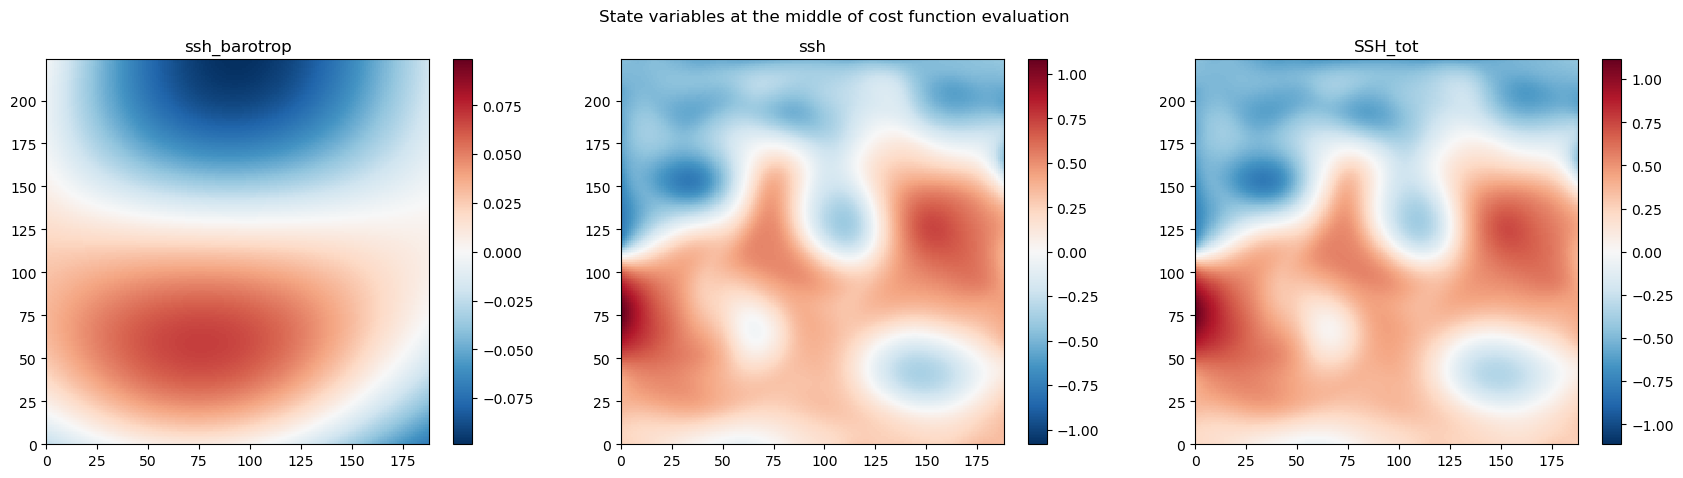

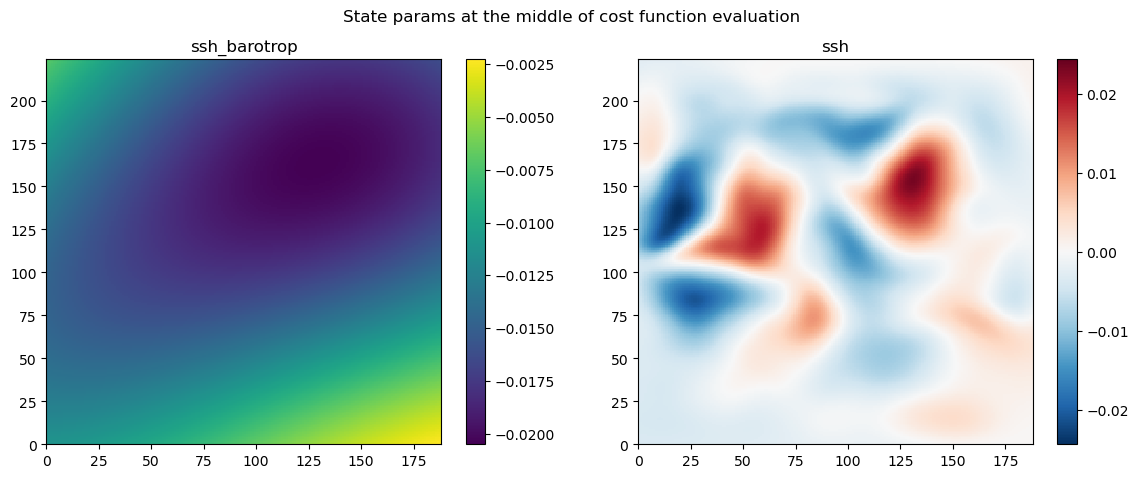

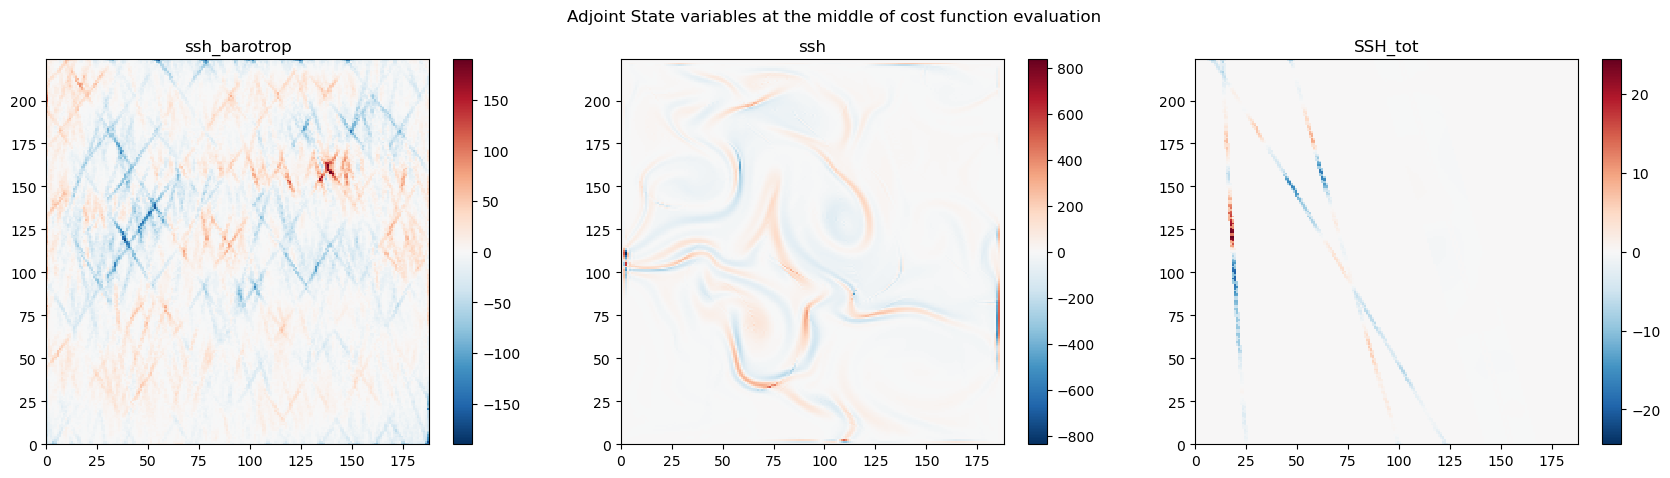

* iteration 40 computed in 4.76E+01 second:, x=7.17E-05, J=3.64E+05, G=5.08E+00, ftol=1.27E-02, gtol=4.83E-01
* iteration 41 computed in 4.69E+01 second:, x=7.33E-05, J=3.63E+05, G=4.36E+00, ftol=4.55E-03, gtol=1.42E-01
* iteration 42 computed in 4.62E+01 second:, x=7.36E-05, J=3.60E+05, G=5.09E+00, ftol=6.89E-03, gtol=1.44E-01
* iteration 43 computed in 4.66E+01 second:, x=7.58E-05, J=3.58E+05, G=6.11E+00, ftol=6.25E-03, gtol=1.66E-01
* iteration 44 computed in 4.64E+01 second:, x=7.03E-05, J=3.54E+05, G=5.26E+00, ftol=1.13E-02, gtol=1.40E-01
* iteration 45 computed in 4.71E+01 second:, x=6.74E-05, J=3.50E+05, G=4.71E+00, ftol=1.19E-02, gtol=1.04E-01
* iteration 46 computed in 4.60E+01 second:, x=6.03E-05, J=3.44E+05, G=5.21E+00, ftol=1.78E-02, gtol=9.52E-02
* iteration 47 computed in 4.73E+01 second:, x=5.76E-05, J=3.39E+05, G=3.46E+00, ftol=1.23E-02, gtol=3.36E-01
* iteration 48 computed in 4.72E+01 second:, x=5.36E-05, J=3.35E+05, G=5.02E+00, ftol=1.30E-02, gtol=3.12E-01
* iteratio

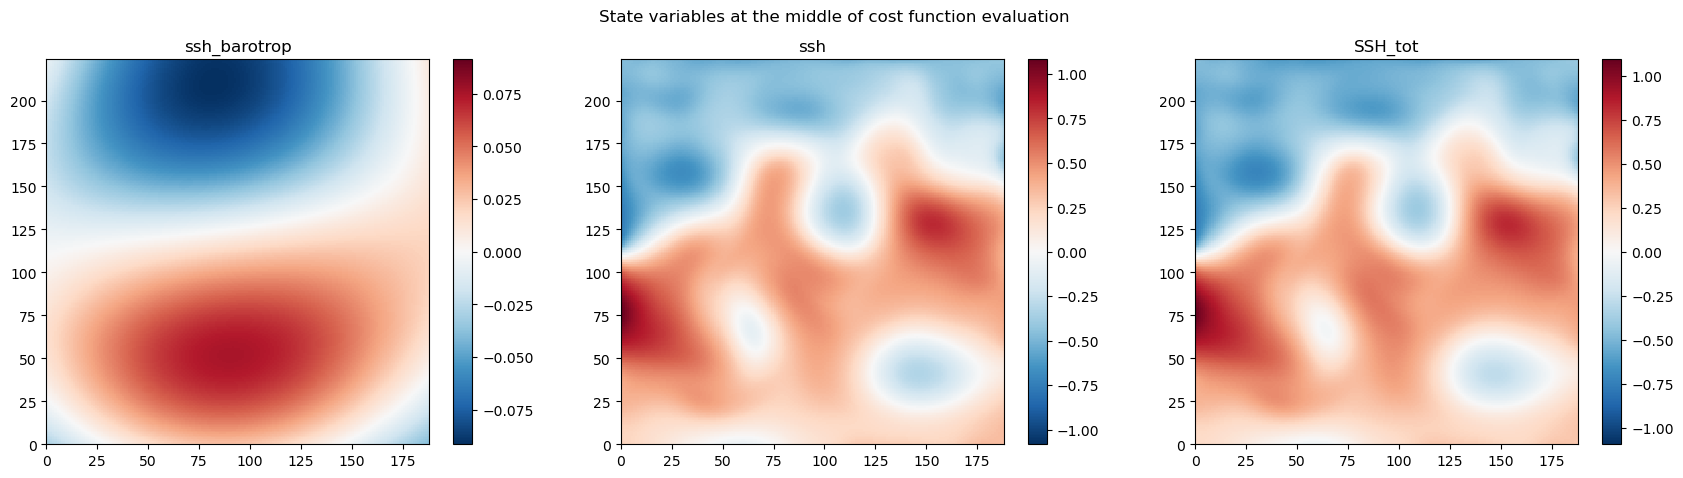

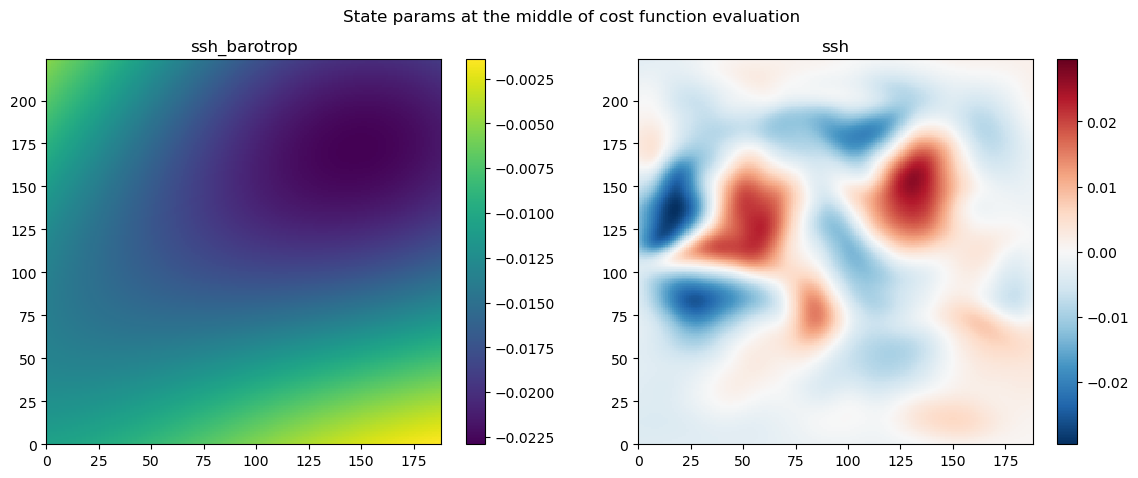

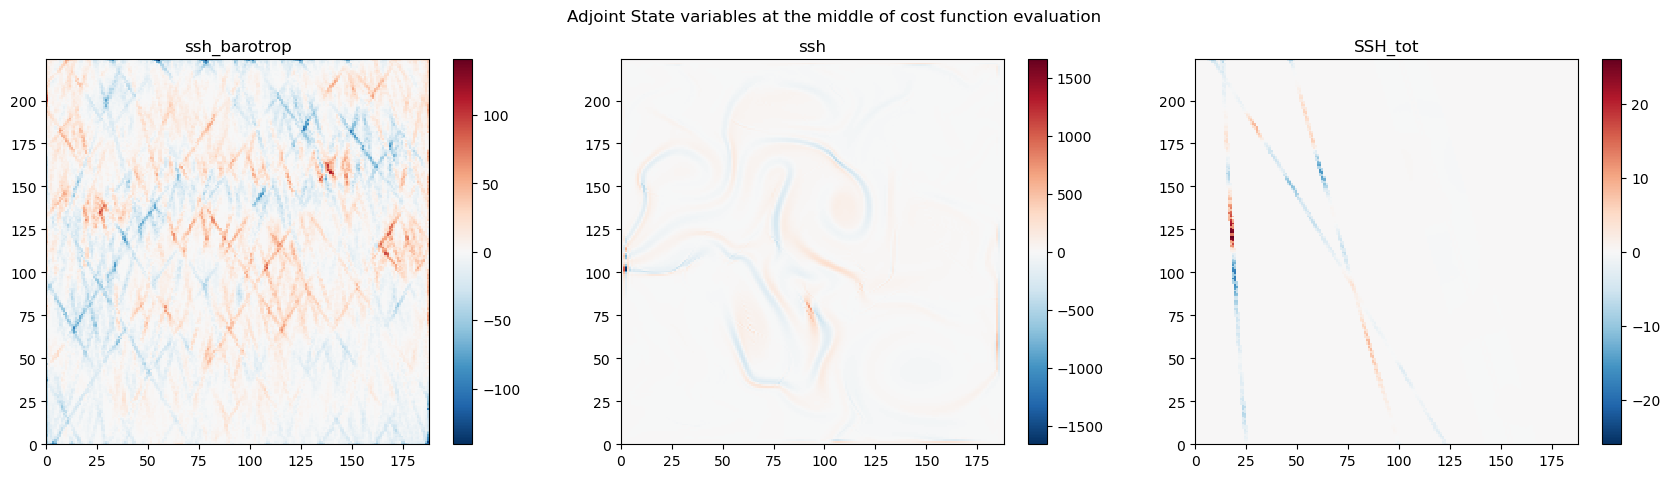

* iteration 50 computed in 4.93E+01 second:, x=3.28E-05, J=3.21E+05, G=5.67E+00, ftol=2.17E-02, gtol=3.64E-01
* iteration 51 computed in 4.87E+01 second:, x=2.01E-05, J=3.25E+05, G=1.39E+01, ftol=1.20E-02, gtol=5.92E-01
* iteration 52 computed in 4.71E+01 second:, x=2.80E-05, J=3.18E+05, G=5.03E+00, ftol=1.96E-02, gtol=6.38E-01


In [ ]:
from src import inv as inv
inv.Inv(config,State,Model,dict_obs=dict_obs,Obsop=Obsop,Basis=Basis,Bc=Bc)  

## Diagnostics

In [ ]:
from src import diag as diag
Diag = diag.Diag(config,State)

In [ ]:
Diag.regrid_exp()

In [ ]:
Diag.rmse_based_scores(plot=True)

In [ ]:
Diag.psd_based_scores(plot=True)

In [ ]:
Diag.movie(framerate=12, cmap='RdBu_r', clim=[-1,1])

In [ ]:
Leaderboard = Diag.Leaderboard()
Leaderboard

### Check observations

In [ ]:
from datetime import datetime
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

# 1. Initialiser un dictionnaire pour stocker les disponibilités par date
resultat_par_date = {}

# 2. Parcourir toutes les observations
for key, values in dict_obs.items():
    if isinstance(key, datetime):
        # Pour chaque satellite, on met à jour la disponibilité (1 si présent au moins une fois)
        for mot in values['obs_name']:
            if key not in resultat_par_date:
                resultat_par_date[key] = {}
            resultat_par_date[key][mot] = 1  # On marque comme disponible

# 3. Remplir les trous (satellites non présents = 0)
tous_les_mots = set()
for dico in resultat_par_date.values():
    tous_les_mots.update(dico.keys())
tous_les_mots = sorted(tous_les_mots)

for date in resultat_par_date:
    for mot in tous_les_mots:
        if mot not in resultat_par_date[date]:
            resultat_par_date[date][mot] = 0

# 4. Créer le DataFrame
df = pd.DataFrame.from_dict(resultat_par_date, orient='index')
df = df[tous_les_mots]  # On s'assure que les colonnes sont dans l'ordre
df = df.sort_index()

# Affichage pour vérification
print(df.head())

# 5. Tracer le graphique de disponibilité par satellite
plt.figure(figsize=(12, 6))
for i, column in enumerate(df.columns):
    plt.step(df.index, df[column] + (i * 1.2), label=column, where='post', linewidth=2)

plt.yticks(ticks=[i * 1.2 + 0.5 for i in range(len(df.columns))], labels=df.columns)
plt.title("Disponibilité des satellites dans le temps")
plt.xlabel("Date")
plt.ylabel("Satellites")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 6. Calculer la somme des 1 pour chaque ligne (chaque date)
df['total_dispo'] = df.sum(axis=1)

# 7. Tracer l'évolution du nombre total de satellites disponibles
plt.figure(figsize=(12, 5))
plt.step(df.index, df['total_dispo'], where='post', color='darkblue', linewidth=2, label='Nombre de satellites')
plt.fill_between(df.index, df['total_dispo'], step="post", alpha=0.2, color='blue')
plt.title("Nombre total de satellites disponibles", fontsize=14)
plt.ylabel("Nombre de satellites", fontsize=12)
plt.xlabel("Temps", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0, df['total_dispo'].max() + 1)
plt.tight_layout()
plt.show()

Vérifier les observations pour une date donnée

In [ ]:
date_a_verifier = datetime(2009, 12, 15)
observations = [obs for date, obs in dict_obs.items() if date == date_a_verifier]

if observations:
    print(f"Observations pour le {date_a_verifier.strftime('%Y-%m-%d')} :")
    for obs in observations:
        print(obs)
else:
    print(f"Aucune observation le {date_a_verifier.strftime('%Y-%m-%d')}.")

Vérifier les dates manquantes dans une plage

In [ ]:
from datetime import timedelta

date_debut = datetime(2009, 12, 1)
date_fin = datetime(2009, 12, 31)
dates_manquantes = []

date_courante = date_debut
while date_courante <= date_fin:
    if date_courante not in dict_obs:
        dates_manquantes.append(date_courante)
    date_courante += timedelta(days=1)

if dates_manquantes:
    print("Dates manquantes :")
    for date in dates_manquantes:
        print(date.strftime('%Y-%m-%d'))
else:
    print("Aucune date manquante dans cette plage.")